# Pre trained network
![imagen](./img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png)

Estas son las arquitecturas de redes neuronales más utilizadas en la comunidad. Para más detalle sobre el funcionamiento de cada red, consultar el [Hands on Machine Learning for Python](https://learning.oreilly.com/library/view/hands-on-machine-learning/9781492032632/ch14.html#cnn_chapter).
* VGG-16
* VGG-19
* Inception V3
* XCeption
* ResNet-50

Las redes se pueden incorporar entrenadas, o sin entrenar.

## ResNet50V2

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
import cv2

from tensorflow.keras.applications.resnet_v2 import ResNet50V2, decode_predictions, preprocess_input

In [2]:
# CODE MODEL
base_model = ResNet50V2(include_top= True, input_shape=(224, 224, 3), weights='imagenet', classifier_activation= 'softmax')

2026-05-07 10:49:06.124414: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-07 10:49:06.124433: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-07 10:49:06.124437: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-07 10:49:06.124628: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-07 10:49:06.125080: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
len(base_model.layers)

192

In [4]:
base_model.summary()

Model: "resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                         

Cargamos algunas imagenes desde local, para ver qué tal funciona la red ResNet50V2 ya entrenada.

In [5]:
# CODE READ DATA

import os

def read_data(path):
    X = []
    for file in os.listdir(path):
        image = imread(path + '/' + file)
        smallimage = cv2.resize(image, (224,224))
        print(path + '/' + file)

        X.append(smallimage)
    return np.array(X)


In [6]:
X_test = read_data('img')

#Preprocesar las imagenes tal y como entran en el model
X_test = preprocess_input(X_test)
print(X_test.shape)

img/dog.11857.jpg
img/cat.8037.jpg
img/horse.jpg
img/dog.11856.jpg
img/bear-1.jpg
img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png
img/cat.8016.jpg
img/pizza.jpg
img/karate.jpg
(9, 224, 224, 3)


In [7]:
# CODE preds

preds = base_model.predict(X_test)

2026-05-07 10:49:08.989493: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 991ms/step


In [8]:
len(preds)

9

In [9]:
preds

array([[2.2135732e-11, 5.2872225e-12, 1.8344097e-11, ..., 6.3644350e-12,
        2.4805127e-11, 4.1531979e-11],
       [8.5168040e-08, 1.4822014e-07, 2.9617492e-08, ..., 6.2942036e-08,
        3.8534429e-07, 2.3654395e-06],
       [6.6322957e-07, 4.3208634e-06, 8.0825193e-06, ..., 1.7418417e-06,
        1.0386803e-05, 2.9400480e-05],
       ...,
       [1.9770725e-05, 5.4083077e-05, 1.6641254e-05, ..., 1.1837184e-05,
        1.1198785e-04, 2.5801471e-04],
       [4.6688864e-08, 3.3564538e-07, 8.2979078e-08, ..., 4.4028374e-07,
        4.2721933e-07, 1.8702467e-08],
       [1.0001806e-07, 7.6349635e-05, 2.6081161e-05, ..., 2.8111351e-06,
        5.1169218e-06, 9.2755654e-06]], dtype=float32)

In [10]:
len(preds[0])

1000

In [11]:
decodes = decode_predictions(preds, top=3)

In [12]:
decodes

[[('n02106030', 'collie', 0.99525696),
  ('n02105855', 'Shetland_sheepdog', 0.004742939),
  ('n12057211', "yellow_lady's_slipper", 9.142558e-09)],
 [('n02124075', 'Egyptian_cat', 0.8209844),
  ('n02127052', 'lynx', 0.12679431),
  ('n02123597', 'Siamese_cat', 0.021530673)],
 [('n02113799', 'standard_poodle', 0.32455903),
  ('n02091831', 'Saluki', 0.30035385),
  ('n02412080', 'ram', 0.123278625)],
 [('n02106550', 'Rottweiler', 0.7329096),
  ('n02112706', 'Brabancon_griffon', 0.085084744),
  ('n02093256', 'Staffordshire_bullterrier', 0.031059297)],
 [('n02132136', 'brown_bear', 0.9994438),
  ('n02112137', 'chow', 0.00054155756),
  ('n02133161', 'American_black_bear', 8.7809785e-06)],
 [('n06359193', 'web_site', 0.8231875),
  ('n03857828', 'oscilloscope', 0.053272214),
  ('n04372370', 'switch', 0.033840638)],
 [('n02124075', 'Egyptian_cat', 0.64984983),
  ('n02123597', 'Siamese_cat', 0.16787378),
  ('n02123159', 'tiger_cat', 0.060449317)],
 [('n07873807', 'pizza', 0.99713033),
  ('n0769372

In [13]:
# CODE decode preds
for j in decodes:
    print('####################')
    for i,decode in enumerate(j):
        print("Predicted:\n", decode[1], decode[2])

####################
Predicted:
 collie 0.99525696
Predicted:
 Shetland_sheepdog 0.004742939
Predicted:
 yellow_lady's_slipper 9.142558e-09
####################
Predicted:
 Egyptian_cat 0.8209844
Predicted:
 lynx 0.12679431
Predicted:
 Siamese_cat 0.021530673
####################
Predicted:
 standard_poodle 0.32455903
Predicted:
 Saluki 0.30035385
Predicted:
 ram 0.123278625
####################
Predicted:
 Rottweiler 0.7329096
Predicted:
 Brabancon_griffon 0.085084744
Predicted:
 Staffordshire_bullterrier 0.031059297
####################
Predicted:
 brown_bear 0.9994438
Predicted:
 chow 0.00054155756
Predicted:
 American_black_bear 8.7809785e-06
####################
Predicted:
 web_site 0.8231875
Predicted:
 oscilloscope 0.053272214
Predicted:
 switch 0.033840638
####################
Predicted:
 Egyptian_cat 0.64984983
Predicted:
 Siamese_cat 0.16787378
Predicted:
 tiger_cat 0.060449317
####################
Predicted:
 pizza 0.99713033
Predicted:
 bagel 0.0011670266
Predicted:
 potpie

## VGG16
En este caso vamos a importar la red VGG16, que utilizaremos como red preentrenada y completaremos con una fully connected layer. 

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

IM_SIZE=32

TRAIN_PATH = '/Users/andoni/Desktop/dogs_cats/train'
filenames = os.listdir(TRAIN_PATH)
categories = []
for filename in filenames:
    category = filename.split('.')[0]
    categories.append(category)
    
df = pd.DataFrame({
    'filenames': filenames,
    'category': categories
})

train_df, validate_df = train_test_split(df,
                                         test_size=0.20,
                                         random_state=42)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [15]:
train_df.head()

,filenames,category
0,cat.1088.jpg,cat
1,cat.1169.jpg,cat
2,cat.91.jpg,cat
3,dog.10489.jpg,dog
4,cat.485.jpg,cat


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Add our data-augmentation parameters to ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255.,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# Note that the validation data should not be augmented!
validation_datagen = ImageDataGenerator(rescale = 1.0/255. )

In [17]:
# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (IM_SIZE, IM_SIZE))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [18]:
from tensorflow.keras.applications.vgg16 import VGG16

# CODE model
base_model = VGG16(input_shape=(IM_SIZE,IM_SIZE,3),
                    include_top=False,
                    weights = 'imagenet'
                )

In [19]:
len(base_model.layers)

19

In [20]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 8, 8, 128)         0     

In [21]:

##### FULLY CONNECTED LAYER #####
# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.25
x = layers.Dropout(0.25)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [22]:
len(model.layers)

23

In [23]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 8, 8, 128)         0     

In [24]:
vgghist = model.fit(train_generator,
                   validation_data = validation_generator,
                   batch_size = 128,
                   epochs = 5)

Epoch 1/5
263/263 [==============================] - 17s 49ms/step - loss: 0.7214 - acc: 0.5951 - val_loss: 0.6858 - val_acc: 0.5935
Epoch 2/5
263/263 [==============================] - 13s 47ms/step - loss: 0.6847 - acc: 0.6049 - val_loss: 0.6861 - val_acc: 0.5935
Epoch 3/5
263/263 [==============================] - 12s 45ms/step - loss: 0.6708 - acc: 0.6146 - val_loss: 0.6756 - val_acc: 0.5935
Epoch 4/5
263/263 [==============================] - 12s 45ms/step - loss: 0.6712 - acc: 0.6122 - val_loss: 0.6756 - val_acc: 0.5935
Epoch 5/5
263/263 [==============================] - 13s 49ms/step - loss: 0.6659 - acc: 0.6162 - val_loss: 0.6766 - val_acc: 0.5935


<Axes: >

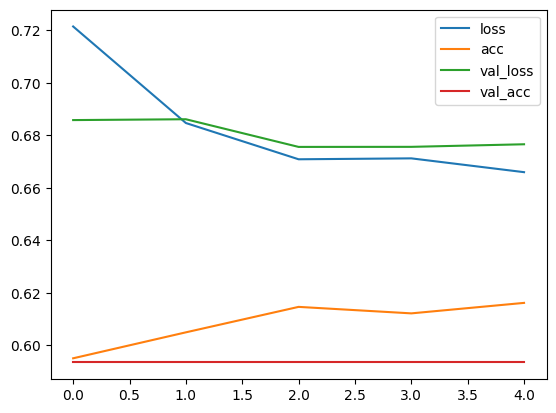

In [25]:
pd.DataFrame(vgghist.history).plot()

## ResNet50V2 sin últimas capas y sin pesos preentrenados

In [26]:
IM_SIZE=32

base_model = ResNet50V2(input_shape = (32, 32, 3),
                       include_top = None,
                       weights = None,
                       classifier_activation= "softmax")


train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (32, 32))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [27]:
len(base_model.layers)

190

In [28]:
base_model.summary()

Model: "resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 38, 38, 3)            0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 16, 16, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 18, 18, 64)           0         ['conv1_conv[0][0]']          
                                                                                         

In [29]:
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.1)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [30]:
len(model.layers)

194

In [31]:
model.fit(train_generator,
         validation_data = validation_generator,
         steps_per_epoch = 100,
         epochs = 20)

Epoch 1/20
100/100 [==============================] - 17s 93ms/step - loss: 1.0718 - acc: 0.5465 - val_loss: 0.6752 - val_acc: 0.5935
Epoch 2/20
100/100 [==============================] - 9s 87ms/step - loss: 0.8010 - acc: 0.5740 - val_loss: 0.6824 - val_acc: 0.5935
Epoch 3/20
100/100 [==============================] - 8s 81ms/step - loss: 0.7657 - acc: 0.5805 - val_loss: 0.9599 - val_acc: 0.5509
Epoch 4/20
100/100 [==============================] - 9s 85ms/step - loss: 0.7509 - acc: 0.5975 - val_loss: 0.6769 - val_acc: 0.5935
Epoch 5/20
100/100 [==============================] - 9s 86ms/step - loss: 0.7215 - acc: 0.6055 - val_loss: 0.6923 - val_acc: 0.5927
Epoch 6/20
100/100 [==============================] - 9s 91ms/step - loss: 0.7456 - acc: 0.5940 - val_loss: 0.6807 - val_acc: 0.5866
Epoch 7/20
100/100 [==============================] - 8s 84ms/step - loss: 0.7717 - acc: 0.5455 - val_loss: 0.8262 - val_acc: 0.5182
Epoch 8/20
100/100 [==============================] - 8s 82ms/step -

In [32]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Escala los píxeles entre 0 y 1

In [33]:
# # Flow validation images in batches of 20 using test_datagen generator
# test_generator = test_datagen.flow_from_dataframe(test_df,
#                                                              TRAIN_PATH,
#                                                              x_col='filenames',
#                                                              y_col='category',
#                                                              batch_size = 20,
#                                                              class_mode = 'binary',
#                                                              target_size = (224, 224))

In [34]:
# loss, accuracy = model.evaluate(validation_generator, verbose=1)